In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from wordcloud import WordCloud
print('All libraries imported successfully!')

All libraries imported successfully!


In [3]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')
from nltk.corpus import stopwords
print('NLTK assets are imported succesfully.')

NLTK assets are imported succesfully.


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\2004s\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\2004s\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [4]:
data = pd.read_csv('Amazon-Product-Reviews-Sentiment-Analysis-in-Python-Dataset.csv')
data.head()

,Review,Sentiment
0,Fast shipping but this product is very cheaply...,1
1,This case takes so long to ship and it's not e...,1
2,Good for not droids. Not good for iPhones. You...,1
3,The cable was not compatible between my macboo...,1
4,The case is nice but did not have a glow light...,1


In [5]:
#prerprocessinng the data and cleaning it
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Review     24999 non-null  object
 1   Sentiment  25000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 390.8+ KB


In [27]:
#balanced dataset


# Convert 1-5 star ratings to binary labels without breaking reruns
sentiment_values = pd.to_numeric(data['Sentiment'], errors='coerce')

if set(sentiment_values.dropna().unique()).issubset({0, 1}):
    data['Sentiment'] = sentiment_values.astype(int)
else:
    data['Sentiment'] = np.where(sentiment_values <= 3, 0, 1).astype(int)

data['Sentiment'].value_counts()

Sentiment
0    15000
1    10000
Name: count, dtype: int64

In [34]:
# removing the stopwords
stop_words = set(stopwords.words('english'))

def clean_review(review):
    if not isinstance(review, str):
        review = '' if pd.isna(review) else str(review)
    review = review.lower()
    cleaned_review = " ".join(
        word for word in review.split()
        if word not in stop_words
    )
    return cleaned_review

data['Review'] = data['Review'].apply(clean_review)


In [39]:
#text normalization
data['Review'] = data['Review'].str.lower()


In [40]:
#removing the punctuation and urls and email addressses
data['Review'] = data['Review'].str.replace(r'[^\w\s]', '', regex=True)
data['Review'] = data['Review'].str.replace(r'http\S+|www\S+|https\S+', '', regex=True)
data['Review'] = data['Review'].str.replace(r'\S+@\S+', '', regex=True)


In [31]:
data.head()

,Review,Sentiment
0,fast shipping product cheaply made brought gra...,0
1,case takes long ship even worth dont buy,0
2,good droids good iphones cannot use features w...,0
3,cable compatible macbook iphone also connector...,0
4,case nice glow light im disappointed product m...,0


In [32]:
data['Sentiment'].value_counts()


Sentiment
0    15000
1    10000
Name: count, dtype: int64

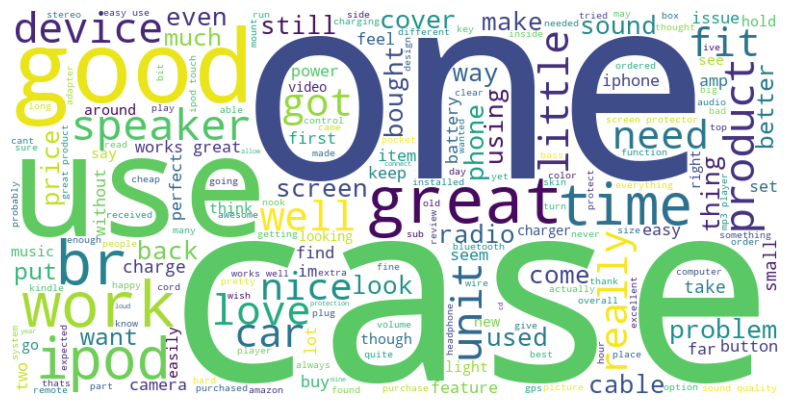

In [33]:
#worclouding your ass
consolidated_rev = ' '.join(word for word in data['Review'] 
[data['Sentiment'] == 1].astype(str))
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(consolidated_rev)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

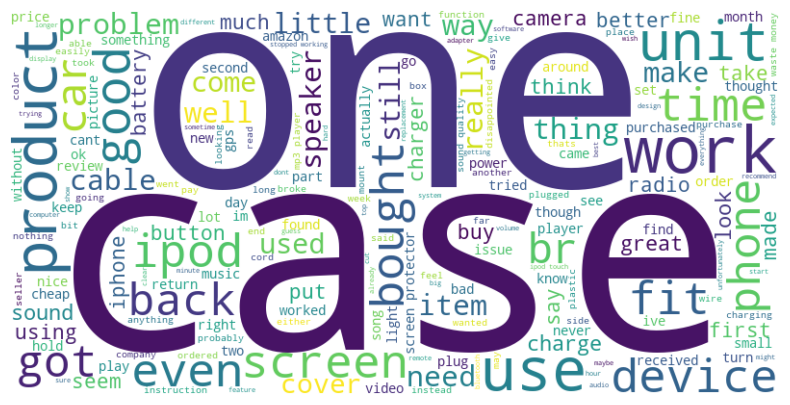

In [35]:
#for the negative reviews
consoliddated_negative_reviews = ' '.join(word for word in data['Review'][data['Sentiment']== 0].astype(str))
wordcloud_neg = WordCloud(width= 800, height=400, background_color='white').generate(consoliddated_negative_reviews
)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.axis('off')
plt.show()


In [41]:
cv = TfidfVectorizer(max_features=10000, ngram_range=(1, 2), min_df=2, sublinear_tf=True)
x = cv.fit_transform(data['Review'])

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    x,
    data['Sentiment'],
    test_size=0.25,
    random_state=42,
    stratify=data['Sentiment']
)


In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model = LogisticRegression(max_iter=1000, C=2.0, solver='liblinear')

# fitting the model
model.fit(x_train, y_train)
print('Model trained successfully!')

# predicting the model
y_pred = model.predict(x_test)

# evaluating the model
accuracy = accuracy_score(y_test, y_pred)
print(f'Logistic Regression Accuracy: {accuracy:.4f}')


Model trained successfully!
Logistic Regression Accuracy: 0.8278


In [43]:
import xgboost as xgb

model = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

# training the model
model.fit(x_train, y_train)
print('XGBoost model trained successfully!')

# Predicting using the XGBoost model
y_pred_xgb = model.predict(x_test)

# Evaluating the XGBoost model
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f'XGBoost Accuracy: {accuracy_xgb:.4f}')


XGBoost model trained successfully!
XGBoost Accuracy: 0.7904


In [47]:

# Ensemble approach: VotingClassifier combining multiple strong learners
from sklearn.ensemble import VotingClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

lr_best = lr_grid.best_estimator_

svm = SVC(
    C=10,
    kernel='rbf',
    gamma='scale',
    class_weight='balanced',
    probability=True,
    random_state=42
)

gb = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    random_state=42
)

# Voting ensemble with soft voting
voting_clf = VotingClassifier(
    estimators=[
        ('lr', lr_best),
        ('svm', svm),
        ('gb', gb)
    ],
    voting='soft',
    n_jobs=-1
)

voting_clf.fit(x_train, y_train)
y_pred_voting = voting_clf.predict(x_test)
accuracy_voting = accuracy_score(y_test, y_pred_voting)
print(f'Ensemble (Voting) Accuracy: {accuracy_voting:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_voting))


Ensemble (Voting) Accuracy: 0.8320

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.87      0.86      3750
           1       0.80      0.77      0.79      2500

    accuracy                           0.83      6250
   macro avg       0.83      0.82      0.82      6250
weighted avg       0.83      0.83      0.83      6250



In [48]:

# Hyperparameter tuning with GridSearchCV for Logistic Regression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix

param_grid = {
    'C': [0.1, 1, 10],
    'class_weight': ['balanced', None],
    'solver': ['liblinear', 'saga']
}

lr_grid = GridSearchCV(
    LogisticRegression(max_iter=2000, random_state=42),
    param_grid,
    cv=5,
    n_jobs=-1,
    scoring='f1'
)

lr_grid.fit(x_train, y_train)
print(f'Best parameters: {lr_grid.best_params_}')
print(f'Best CV F1 Score: {lr_grid.best_score_:.4f}')

y_pred_tuned = lr_grid.predict(x_test)
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
print(f'Tuned Logistic Regression Accuracy: {accuracy_tuned:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_tuned))


Best parameters: {'C': 1, 'class_weight': 'balanced', 'solver': 'liblinear'}
Best CV F1 Score: 0.7748
Tuned Logistic Regression Accuracy: 0.8245

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.83      0.85      3750
           1       0.76      0.82      0.79      2500

    accuracy                           0.82      6250
   macro avg       0.82      0.82      0.82      6250
weighted avg       0.83      0.82      0.83      6250

